# 📘 Praktikum Machine Learning - Pertemuan 3
## Data Preparation Lanjutan: *Missing Value, Outlier,* dan *Imbalanced Data*

| | |
|:--|:--|
| **Nama** | Dhani Kurnia Ramdani |
| **NPM** | 202343500139 |
| **Mata Kuliah** | Machine Learning |

---

### 🎯 Tujuan
Membangun alur *data preparation* lengkap pada data sintetis, lalu membandingkan model klasifikasi **dengan** dan **tanpa** penanganan data tidak seimbang.

### 🗺️ Alur Kerja

| No | Tahap | Teknik |
|:-:|:--|:--|
| 1 | Persiapan library | `numpy`, `pandas`, `scikit-learn`, `imbalanced-learn` |
| 2 | Import dataset | `make_classification` + simulasi *missing value* 5% |
| 3 | Preprocessing | Split data → `KNNImputer` → `IsolationForest` |
| 4 | Training model | `LogisticRegression` tanpa dan dengan `SMOTE` |
| 5 | Evaluasi | Akurasi, F1-Score, `classification_report` |
| 6 | Visualisasi | Distribusi kelas sebelum dan sesudah SMOTE |

---
## 1️⃣ Persiapan Library
Mengimpor semua *library* yang dibutuhkan: pengolah data (`numpy`, `pandas`), model dan metrik (`scikit-learn`), serta `SMOTE` dari `imbalanced-learn`.

> 💡 Jika muncul `ModuleNotFoundError: imblearn`, pasang dulu dengan `python -m pip install imbalanced-learn`.

In [1]:
# 1 Persiapan Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report

---
## 2️⃣ Import Dataset
Data dibuat secara sintetis: **2000 baris**, **8 fitur**, dengan rasio kelas **95% : 5%** (sengaja tidak seimbang). Setelah itu, 5% sel pada kolom fitur dikosongkan secara acak untuk mensimulasikan *missing value*.

> 📌 `random_state` ditetapkan agar hasil bisa direproduksi.

In [2]:
# 2 Import Dataset

# Dataset sintetis: 2000 baris, 8 fitur, kelas minoritas 5%
X, y = make_classification(n_samples=2000, n_features=8,
                           weights=[0.95, 0.05], random_state=7)
fitur_cols = [f"fitur_{i}" for i in range(8)]
df = pd.DataFrame(X, columns=fitur_cols)
df["target"] = y

# Kosongkan 5% sel pada kolom fitur saja
rng = np.random.default_rng(7)
df[fitur_cols] = df[fitur_cols].mask(rng.random((len(df), 8)) < 0.05)
print(df.isnull().sum())

fitur_0    110
fitur_1     98
fitur_2     92
fitur_3    108
fitur_4     90
fitur_5     78
fitur_6    104
fitur_7    110
target       0
dtype: int64


---
## 3️⃣ Preprocessing
Tiga langkah berurutan:

1. **Split data** (80% latih, 20% uji, `stratify=y`) supaya proporsi kelas minoritas terjaga di kedua bagian.
2. **KNN Imputer** (`k=5`) mengisi nilai kosong dengan meminjam nilai dari 5 baris paling mirip.
3. **Isolation Forest** (`contamination=0.02`) menandai titik yang paling mudah "diisolasi" sebagai *outlier*, lalu baris tersebut dibuang dari data latih.

> ⚠️ **Mencegah data leakage:** imputer dan detektor outlier hanya `fit` pada **data latih**. Data uji hanya ditransformasi, sehingga evaluasi tetap jujur.

In [3]:
# 3 Preprocessing

# Split dulu, supaya imputer & outlier detector hanya belajar dari data latih
X_train, X_test, y_train, y_test = train_test_split(
    df[fitur_cols], df["target"], test_size=0.2, stratify=df["target"], random_state=7)

# Imputasi KNN: fit di train, transform di train dan test
imputer = KNNImputer(n_neighbors=5)
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=fitur_cols, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=fitur_cols, index=X_test.index)

# Deteksi outlier dengan Isolation Forest (hanya data latih)
iso = IsolationForest(contamination=0.02, random_state=7)
is_outlier = iso.fit_predict(X_train) == -1
print("Jumlah outlier terdeteksi:", is_outlier.sum())

# Buang outlier dari data latih
X_train, y_train = X_train[~is_outlier], y_train[~is_outlier]

Jumlah outlier terdeteksi: 32


---
## 4️⃣ Training Model (dengan dan tanpa SMOTE)
Dua model `LogisticRegression` dilatih sebagai pembanding:

| Model | Data latih |
|:--|:--|
| **Baseline** | Data asli (tidak seimbang) |
| **SMOTE** | Data asli + sampel sintetis kelas minoritas |

> ⚠️ **SMOTE hanya dipasang pada data latih.** Menerapkannya pada data uji akan membuat skor evaluasi palsu.

In [4]:
# 4 Training Model (dengan dan tanpa SMOTE)

# Tanpa penanganan imbalance
model_base = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Dengan SMOTE (HANYA pada train set)
X_train_sm, y_train_sm = SMOTE(random_state=7).fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000).fit(X_train_sm, y_train_sm)

---
## 5️⃣ Evaluasi
Model diuji pada data uji yang **tidak disentuh** oleh imputer, detektor outlier, maupun SMOTE.

| Metrik | Cara membaca |
|:--|:--|
| **Akurasi** | Persentase tebakan benar. Bisa menipu saat kelas tidak seimbang. |
| **Precision** | Dari yang ditebak positif, berapa yang benar-benar positif. |
| **Recall** | Dari yang benar-benar positif, berapa yang berhasil terdeteksi. |
| **F1-Score** | Rata-rata harmonik precision dan recall. |

In [5]:
# 5 Evaluasi

for nama, model in [("Baseline (tanpa SMOTE)", model_base), ("Dengan SMOTE", model_smote)]:
    y_pred = model.predict(X_test)
    print(f"--- {nama} ---")
    print("Akurasi :", round(accuracy_score(y_test, y_pred), 3))
    print("F1-Score:", round(f1_score(y_test, y_pred), 3))
    print(classification_report(y_test, y_pred, digits=3))

--- Baseline (tanpa SMOTE) ---
Akurasi : 0.983
F1-Score: 0.829
              precision    recall  f1-score   support

           0      0.989     0.992     0.991       379
           1      0.850     0.810     0.829        21

    accuracy                          0.983       400
   macro avg      0.920     0.901     0.910       400
weighted avg      0.982     0.983     0.982       400

--- Dengan SMOTE ---
Akurasi : 0.935
F1-Score: 0.606
              precision    recall  f1-score   support

           0      0.997     0.934     0.965       379
           1      0.444     0.952     0.606        21

    accuracy                          0.935       400
   macro avg      0.721     0.943     0.785       400
weighted avg      0.968     0.935     0.946       400



### 📊 Ringkasan Hasil

| Model | Akurasi | Precision (kelas 1) | Recall (kelas 1) | F1 (kelas 1) |
|:--|:-:|:-:|:-:|:-:|
| Baseline | 0,983 | 0,850 | 0,810 | **0,829** |
| SMOTE | 0,935 | 0,444 | **0,952** | 0,606 |

### 📝 Analisis
- **SMOTE menaikkan recall** (0,810 → 0,952): hampir semua kelas minoritas berhasil terdeteksi.
- **Harganya adalah precision** (0,850 → 0,444): model jadi banyak salah menuding kelas 0 sebagai kelas 1, sehingga F1 dan akurasi ikut turun.
- Jadi pada data ini SMOTE bukan "lebih baik" secara umum, melainkan **menukar precision dengan recall**. Pilihannya bergantung pada kebutuhan: jika melewatkan kasus positif sangat mahal (misalnya deteksi penyakit), SMOTE layak dipakai.
- ⚠️ **Catatan kehati-hatian:** data uji hanya berisi **21** sampel kelas minoritas, jadi selisih kecil bisa terjadi karena kebetulan. Untuk kesimpulan yang lebih kokoh, gunakan *cross-validation*.

---
## 6️⃣ Visualisasi
Grafik batang membandingkan jumlah sampel tiap kelas pada **data latih** sebelum dan sesudah SMOTE. Setelah SMOTE, kedua kelas jumlahnya setara.

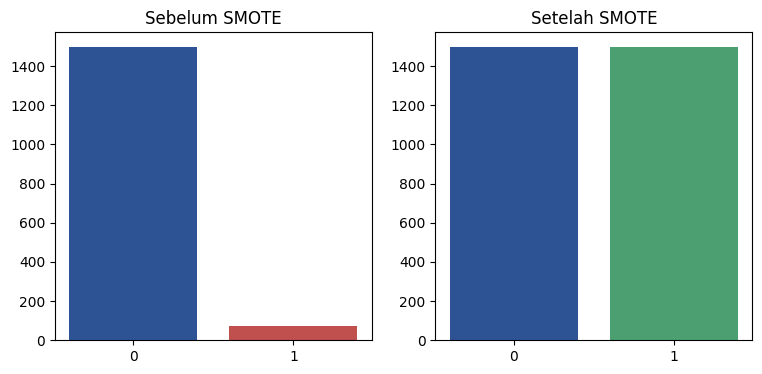

In [6]:
# 6 Visualisasi

before = y_train.value_counts()
after = pd.Series(y_train_sm).value_counts()
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(before.index.astype(str), before.values, color=["#2E5395", "#C0504D"])
axes[0].set_title("Sebelum SMOTE")

axes[1].bar(after.index.astype(str), after.values, color=["#2E5395", "#4C9F70"])
axes[1].set_title("Setelah SMOTE")

plt.show()

---
## ✅ Kesimpulan Akhir

1. **Alur preprocessing** (split → imputasi KNN → deteksi outlier) berjalan tanpa kebocoran data karena semua transformer hanya belajar dari data latih.
2. **Akurasi menipu** pada data tidak seimbang: kedua model berakurasi di atas 0,93, tetapi kualitas deteksi kelas minoritas hanya terlihat dari precision, recall, dan F1.
3. **SMOTE** menyeimbangkan kelas dan menaikkan recall secara drastis, dengan konsekuensi turunnya precision. Pemilihan metode harus mengikuti tujuan penerapan model.